In [1]:
import os
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from scipy.stats import wilcoxon
from itertools import combinations

In [2]:
with open('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/imb_files/final_hpt_choices.pkl', 'rb') as f:
    final_choices = pickle.load(f)
    
params = final_choices['5s_0.5']['params']

In [3]:
params

{'n_estimators': 170.0,
 'max_depth': 18.0,
 'min_samples_split': 8.0,
 'min_samples_leaf': 9.0,
 'max_features': 'sqrt',
 'bootstrap': True}

In [4]:
base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_5s_yo_0.5.csv'

In [5]:
features = pd.read_csv(base_path)

# groups = test_data['experiment_id']

features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)

# split data
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]



In [6]:
model = RandomForestClassifier(random_state=42)
rf = RandomForestClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            min_samples_split=int(params['min_samples_split']),
            min_samples_leaf=int(params['min_samples_leaf']),
            max_features=params['max_features'],
            bootstrap=params['bootstrap']
        )


In [7]:
class_names = ['pre-void', 'void', 'post-void']

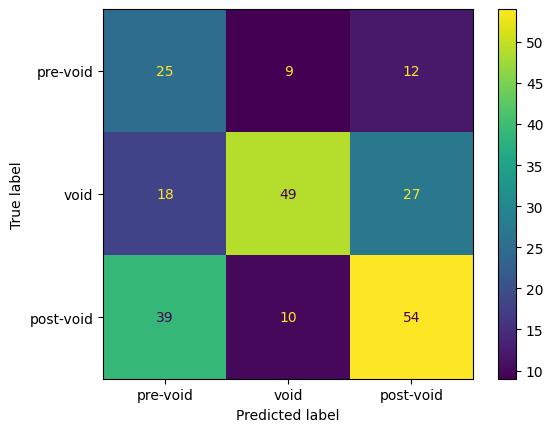

              precision    recall  f1-score   support

    pre-void       0.30      0.54      0.39        46
        void       0.72      0.52      0.60        94
   post-void       0.58      0.52      0.55       103

    accuracy                           0.53       243
   macro avg       0.54      0.53      0.52       243
weighted avg       0.58      0.53      0.54       243

Accuracy: 0.5267489711934157


In [8]:
# # Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
        
# model.fit(X_train_resampled, y_train_encoded)
# y_pred = (model.predict(X_test))
model.fit(X_train, y_train_encoded)
y_pred = label_encoder.inverse_transform(model.predict(X_test))
    
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['pre-void', 'void', 'post-void'])
cm_display.plot()
# plt.title(f'Confusion Matrix: ')
plt.show()
    
    
# print(f"Classification Report: {exp_name} ")
print(classification_report(y_test, y_pred, labels=class_names))
print("Accuracy:", accuracy_score(y_test, y_pred))

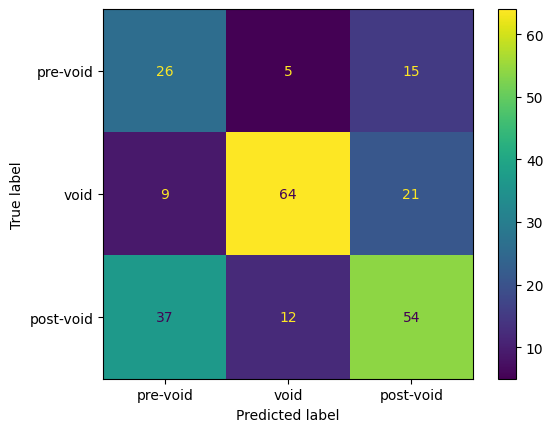

              precision    recall  f1-score   support

    pre-void       0.36      0.57      0.44        46
        void       0.79      0.68      0.73        94
   post-void       0.60      0.52      0.56       103

    accuracy                           0.59       243
   macro avg       0.58      0.59      0.58       243
weighted avg       0.63      0.59      0.60       243

Accuracy: 0.5925925925925926


In [9]:
# # Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
        
# rf.fit(X_train_resampled, y_train_encoded)
# y_pred = (rf.predict(X_test))
rf.fit(X_train, y_train_encoded)
y_pred = label_encoder.inverse_transform(rf.predict(X_test))
    
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['pre-void', 'void', 'post-void'])
cm_display.plot()
# plt.title(f'Confusion Matrix: ')
plt.show()
    
    
# print(f"Classification Report: {exp_name} ")
print(classification_report(y_test, y_pred, labels=class_names))
print("Accuracy:", accuracy_score(y_test, y_pred))